## SDM274 Assignment 07 - Decision Tree

**Requirements**

1. Read and understand a decision tree and its visualization code;

2. Use a portion of the data as the test dataset, and verify the classification performance of the decision tree using the test dataset. Evaluate using accuracy as the metric.

3. During the code execution, you may encounter issues with the graphviz environment in the decision tree visualization part. Depending on your computer's operating system, you can search online for how to install graphviz and configure the correct path.

**Modifications**

First decisiontreeplotter.py uses graphviz for plotting, but after a brief search the Python APIs for graphviz installed are all `pygraphviz`, so I haven't found out if it's the version or something else. The plotting process isn't a big deal, it's mostly about adding nodes and edges, so I checked the documentation and changed the original code to use `pygraphviz` for plotting:

```python
import pygraphviz as pgv

class DecisionTreePlotter:
    def __init__(self, tree, feature_names = None, label_names = None) -> None:
        self.tree = tree
        self.feature_names = feature_names
        self.label_names = label_names
        self.graph = pgv.AGraph(strict = True, directed = True)

    def _build(self, dt_node):
        if dt_node.children:
            feature_desc = self.feature_names[dt_node.feature_index]
            if self.feature_names:
                label = feature_desc['name']
            else:
                label = str(dt_node.feature_index)

            self.graph.add_node(str(id(dt_node)), label=label, shape="box")

            for feature_value, dt_child in dt_node.children.items():
                self._build(dt_child)
                feature_value_desc = feature_desc.get("value_names")
                if feature_value_desc:
                    edge_label = feature_value_desc[feature_value]
                else:
                    edge_label = str(feature_value)

                self.graph.add_edge(str(id(dt_node)), str(id(dt_child)), label=edge_label)
        else:
            if self.label_names:
                label = self.label_names[dt_node.value]
            else:
                label = str(dt_node.value)

            self.graph.add_node(str(id(dt_node)), label = label, shape = "ellipse")

    def plot(self, output_file = "decision_tree.png"):
        self._build(self.tree)
        self.graph.layout(prog = "dot")
        self.graph.draw(output_file)
```

Next, as in the example code, implement and introduce the decision tree:

In [181]:
import numpy as np
import matplotlib.pyplot as plt

import decision_tree as DT
from decisiontreeplotter import DecisionTreePlotter

import importlib

importlib.reload(DT)

<module 'decision_tree' from '/home/gralerfics/MyFiles/Workspace/SUSTech-SDM274-AI-and-Machine-Learning-Assignments/HA07_Decision_Tree/lec07_dt/decision_tree.py'>

The original code is then slightly modified as required to divide the dataset into a training set and a test set:

In [182]:
def random_split(X, y, test_size = 0.3, seed = None):
    if seed is not None:
        np.random.seed(seed)

    indices = np.arange(len(X))
    np.random.shuffle(indices)

    split_index = int(len(X) * (1 - test_size))
    train_indices, test_indices = indices[:split_index], indices[split_index:]

    X_train, y_train = X[train_indices], y[train_indices]
    X_test, y_test = X[test_indices], y[test_indices]

    return X_train, y_train, X_test, y_test

In [183]:
data = np.loadtxt('../dataset/lenses/lenses.data', dtype = int)

X = data[:, 1:-1]
y = data[:, -1]

X_train, y_train, X_test, y_test = random_split(X, y, test_size = 0.2) # , seed = 42)

print(X_train, '\n', y_train, '\n', X_test, '\n', y_test)

[[3 1 1 1]
 [1 2 1 2]
 [1 1 2 2]
 [3 1 2 1]
 [2 1 1 1]
 [2 2 2 2]
 [2 1 2 2]
 [1 2 2 2]
 [1 1 1 2]
 [1 1 1 1]
 [3 2 1 1]
 [3 1 2 2]
 [2 2 1 2]
 [3 2 1 2]
 [3 2 2 2]
 [2 1 2 1]
 [1 2 1 1]
 [3 1 1 2]
 [2 2 2 1]] 
 [3 2 1 3 3 3 1 1 2 3 3 1 2 2 3 3 3 3 3] 
 [[1 2 2 1]
 [2 1 1 2]
 [3 2 2 1]
 [1 1 2 1]
 [2 2 1 1]] 
 [3 2 3 3 3]


Then training is performed to construct a decision tree:

In [184]:
dt = DT.DecisionTree()
dt.train(X_train, y_train)
print(dt)


Internal node <3>:
	[1]-> Leaf node (3)
	[2]-> Internal node <2>:
		[1]-> Internal node <0>:
			[1]-> Leaf node (2)
			[2]-> Leaf node (2)
			[3]-> Internal node <1>:
				[1]-> Leaf node (3)
				[2]-> Leaf node (2)
			
		
		[2]-> Internal node <1>:
			[1]-> Leaf node (1)
			[2]-> Internal node <0>:
				[1]-> Leaf node (1)
				[2]-> Leaf node (3)
				[3]-> Leaf node (3)
			
		
	



And the classification performance of the decision tree is verified using a test set:

In [185]:
y_pred = dt.predict(X_test)
accuracy = np.mean(y_pred == y_test)
print(f'Accuracy: {accuracy * 100:.2f} %')

Accuracy: 100.00 %


Multiple runs show that the accuracy is basically above 80%, which is a good performance; however, because the dataset is too small, the resultant accuracy is greatly affected by the division of the training set and the test set, so the accuracy fluctuates to a certain extent.

Drawing the decision tree:

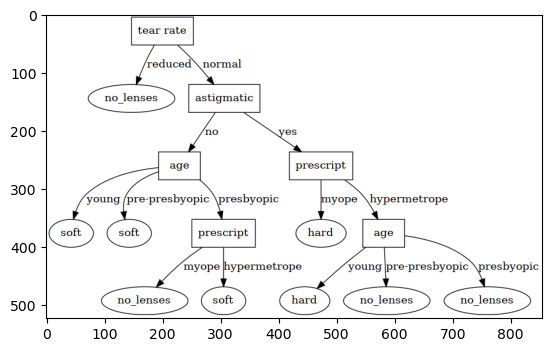

In [186]:
features_dict = {
    0: {'name': 'age', 'value_names': {1:'young', 
                                       2:'pre-presbyopic',
                                       3:'presbyopic'}
        },
    1: {'name':'prescript', 
        'value_names': {1: 'myope',
                        2: 'hypermetrope'}
        },
    2: {'name': 'astigmatic', 
        'value_names': {1: 'no', 
                        2: 'yes'}
    },
    3: {'name': 'tear rate', 
        'value_names': {1:'reduced', 
                        2:'normal'}
        },
}

label_dict = {
    1: 'hard',
    2: 'soft',
    3: 'no_lenses',
}

dtp = DecisionTreePlotter(dt.tree_, feature_names = features_dict, label_names=label_dict)
dtp.plot(output_file = "decision_tree.png")

plt.imshow(plt.imread('decision_tree.png'))